# Activity 4 – Support Vector Machine (SVM) Classification
**Dataset:** Seattle Weather | TC2004B — A01286400

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample
import warnings; warnings.filterwarnings('ignore')

## 1. Load Data & Class Balance Analysis

In [2]:
df = pd.read_csv('../../../data/s2/seattle-weather.csv').drop(columns=['date'])
X = df.drop(columns=['weather'])
y = df['weather']
counts_before = y.value_counts()
print('Class distribution before balancing:')
print(counts_before)

Class distribution before balancing:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


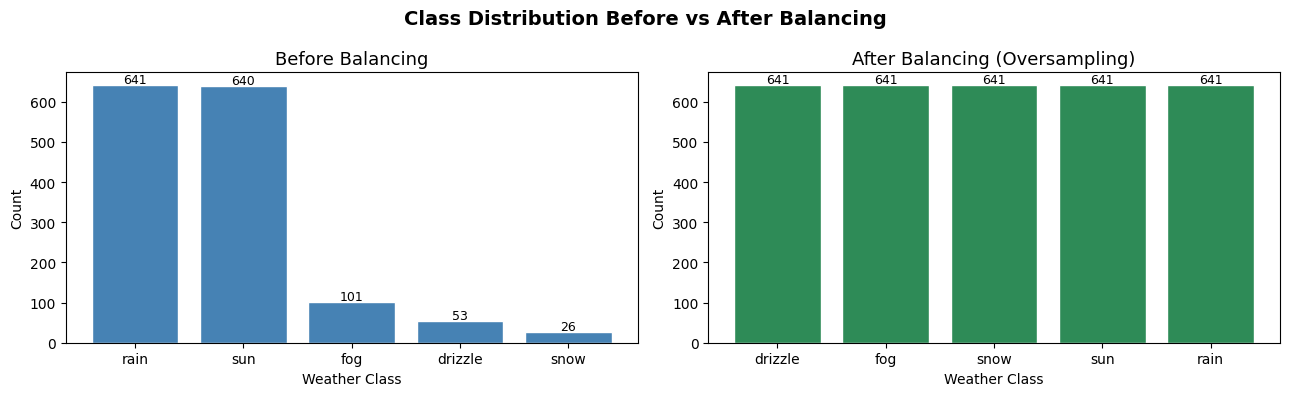

In [3]:
# Oversample minority classes
df_combined = pd.concat([X, y], axis=1)
max_count = counts_before.max()
dfs = [resample(df_combined[df_combined['weather'] == lbl],
               replace=True, n_samples=max_count, random_state=42)
       for lbl in y.unique()]
df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
X_bal = df_bal.drop('weather', axis=1)
y_bal = df_bal['weather']
counts_after = y_bal.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(counts_before.index, counts_before.values, color='steelblue', edgecolor='white')
axes[0].set_title('Before Balancing', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)
axes[1].bar(counts_after.index, counts_after.values, color='seagreen', edgecolor='white')
axes[1].set_title('After Balancing (Oversampling)', fontsize=13)
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)
for ax in axes:
    ax.set_xlabel('Weather Class')
plt.suptitle('Class Distribution Before vs After Balancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} (70/30 split)')

Train: 2243 | Test: 962 (70/30 split)


## 2. Feature Scaling

SVM finds optimal hyperplanes using distances from support vectors. Features must be on the same scale.

In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print('Features scaled with StandardScaler')

Features scaled with StandardScaler


## 3. SVM Classifier — Manual Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| `kernel` | `'rbf'` | RBF maps data to high-dim space; captures non-linear weather boundaries |
| `C` | 10 | Higher C → smaller margin, fewer training misclassifications. C=10 gives good fit without extreme overfitting |
| `gamma` | `'scale'` | `1 / (n_features * X.var())` — automatically adapts to data spread |

> SVM uses **One-vs-Rest** strategy for multi-class classification.

In [6]:
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)
y_pred = svm.predict(X_test_sc)
print('SVM Classification Report:')
print(classification_report(y_test, y_pred))

SVM Classification Report:
              precision    recall  f1-score   support

     drizzle       0.61      0.56      0.59       193
         fog       0.50      0.61      0.55       192
        rain       0.98      0.79      0.87       192
        snow       0.95      1.00      0.97       193
         sun       0.59      0.59      0.59       192

    accuracy                           0.71       962
   macro avg       0.73      0.71      0.72       962
weighted avg       0.73      0.71      0.72       962



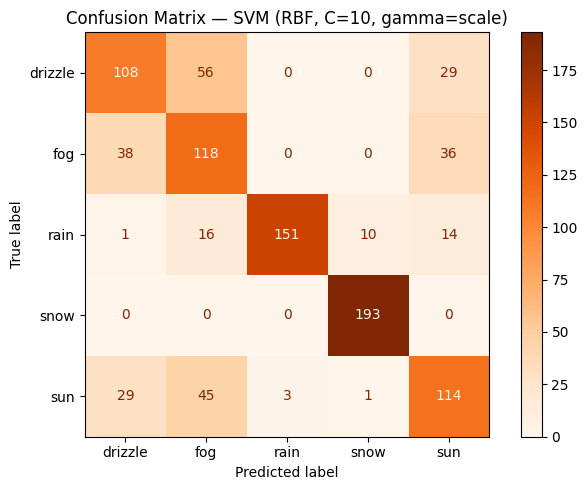

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Oranges')
ax.set_title('Confusion Matrix — SVM (RBF, C=10, gamma=scale)')
plt.tight_layout()
plt.show()

## 4. Effect of C on Accuracy

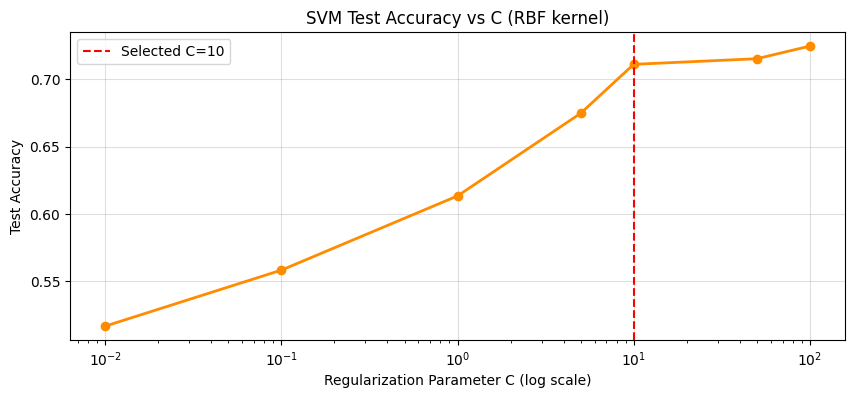

In [8]:
C_values = [0.01, 0.1, 1, 5, 10, 50, 100]
accuracies = []
for c in C_values:
    svm_c = SVC(kernel='rbf', C=c, gamma='scale', random_state=42)
    svm_c.fit(X_train_sc, y_train)
    accuracies.append(svm_c.score(X_test_sc, y_test))

plt.figure(figsize=(10, 4))
plt.semilogx(C_values, accuracies, marker='o', color='darkorange', linewidth=2)
plt.axvline(x=10, color='red', linestyle='--', label='Selected C=10')
plt.xlabel('Regularization Parameter C (log scale)')
plt.ylabel('Test Accuracy')
plt.title('SVM Test Accuracy vs C (RBF kernel)')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

## 5. Reflection

**Hyperparameter impact:**
- **`kernel='rbf'`:** The RBF (Gaussian) kernel projects data into infinite-dimensional space, enabling separation of classes that are not linearly separable in the original feature space. It works well when class boundaries are complex, as expected with 5 weather types defined by overlapping numerical features.
- **`C=10`:** C controls the margin-violation penalty. High C → narrow margin, fewer training errors but risk of overfitting. Low C → wide margin, more misclassifications but better generalization. C=10 favors a tighter fit, appropriate for a dataset with enough training samples after oversampling.
- **`gamma='scale'`:** Controls the influence radius of each support vector. `scale` computes gamma automatically as $1/(n_{features} \cdot Var(X))$, ensuring proper scaling without manual adjustment.

**SVM strengths for this dataset:**
- Effective in high-dimensional spaces and with clear margin between classes
- Robust when the dataset is properly scaled

**Limitation:** SVMs are slower to train than tree-based methods, and the model is not directly interpretable (no feature importance or tree structure).